In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from sympy import symbols, simplify, solve, binomial, summation, sqrt, factorial, exp, oo, expand, latex

In [3]:
from scipy.stats import bernoulli, binom, poisson

## Expamples

Consider a health care worker without the flu. 
Suppose that they have a $p=0.01$ probability of getting infected after an examination of an infected patient. 
His chance of getting infected after the $i\mathrm{th}$ interaction is assumed to be $p(1−p)^{i−1}$ for $i = 1, 2, \dots$.
What is the probability of his getting infected after 3 or more interactions expressed as to the nearest integer percentage? (That is, no decimal places.)

In [60]:
i = symbols('i', real=True, positive=True)
p0=0.01
pmf = p0*(1-p0)**(i-1)
cdf3 = summation(pmf, (i, 1, 2))
simplify(expand(1-cdf3))

0.980100000000000

Consider a geometric **random variable**, $X$ which has mass function $p(1−p)^{x−1}$ for $x=1, 2, \dots$. 
(You can assume this sums to 1.) What is the probability $X > 5$?

In [53]:
x, p = symbols('x p', real=True, positive=True)
pmf = p*(1-p)**(x-1)
s5 = summation(pmf, (x, 6, oo))
simplify(s5)

Piecewise((-(p - 1)**5, p < 2), (p*Sum((1 - p)**(x - 1), (x, 6, oo)), True))

Suppose that a person is flipping  a biased coin with success probability $p$. 
She flips the coin 10 times yielding 1 head. 
Consider two possibilities:  
- the person planned on flipping the coin ten times and got one head, 
- the person planned to flip the coin until the first head and it took ten times. 

What can you say about the likelihood in these two circumstances?

In [9]:
x, p = symbols('x p', real=True, positive=True)
pmfGeom = p*(1-p)**(10-1)
pmfBinomial = binomial(10, 1)*p**1*(1-p)**(10-1)
print(f"Geometric: {latex(pmfGeom)}\n Binomial: {latex(pmfBinomial)}")

Geometric: p \left(1 - p\right)^{9}
 Binomial: 10 p \left(1 - p\right)^{9}


You flip a fair coin 5 times, what's the probability of getting 4 or 5 heads?

In [8]:
1-binom.cdf(3, n=5, p=0.5)

np.float64(0.1875)

In [6]:
x = symbols('x', real=True, positive=True)
pmf = binomial(3, x)*(0.5)**x*(1-0.5)**(3-x)
cdf = summation(pmf, (x, 1, 3))
cdf

0.875000000000000

The Poisson mass function is given by 
$P(X=x)=\frac{e^{-\lambda}\lambda^x}{x!}$ for $x = 0, 1, 2, 3, \dots$ 
and $\lambda>0$. 
What is $\mathbb{E}\big(X(X−1)\big)$ where $X$ is a **Poisson random variable**?

In [54]:
x, lamb = symbols('x lamb', real=True, positive=True)
pmf = lamb**x * exp(-lamb)/factorial(x)
simplify(summation(pmf*(x*(x-1)), (x, 0, oo)))

lamb**2

## Bernoulli

In [4]:
# Define the probability of success (p)
p = 0.7
num_samples = 20

### Generating

In [ ]:
# Generate a single Bernoulli trial outcome
single_outcome = bernoulli.rvs(p)
print(f"Single Bernoulli outcome: {single_outcome}")

Single Bernoulli outcome: 1


In [5]:
# Generate multiple Bernoulli trial outcomes
samples = bernoulli.rvs(p, size=num_samples)
print(f"Multiple Bernoulli samples: {samples}")

Multiple Bernoulli samples: [0 1 1 1 0 0 1 0 1 0 1 0 1 1 1 1 1 1 1 1]


### Distribution

#### Probability Mass Function (`.pmf`)

In [5]:
# Probability of failure (x=0)
p=0.6
prob_failure = bernoulli.pmf(0, p)
# Probability of success (x=1)
prob_success = bernoulli.pmf(1, p)
print(f"Probability of failure (0): {prob_failure}", "\n" 
      f"Probability of success (1): {prob_success}")

Probability of failure (0): 0.4000000000000001 
Probability of success (1): 0.6


#### Cumulative Distribution Function (`.cdf`)

In [6]:
# CDF at 1 (probability of success or less)
cdf_at_1 = bernoulli.cdf(1, p)
print(f"CDF at 1: {cdf_at_1}")

CDF at 1: 1.0


#### Quantiles (`.ppf`)

In [38]:
# PPF at 0.7 (probability of success or less)
ppf_at_07 = bernoulli.ppf(0.7, p)
print(f"PPF at 0.7: {ppf_at_07}")

PPF at 0.7: 1.0


#### Mean or expected value (`.mean`)

In [7]:
bernoulli.mean(p=p)

np.float64(0.6)

#### Variances (`.var`) and Standard Deviation (`.std`)

In [36]:
10*bernoulli.var(p=.5)

np.float64(2.5)

In [4]:
bernoulli.var(p=p)

np.float64(0.21000000000000002)

In [7]:
bernoulli.std(p=p)

np.float64(0.45825756949558405)

In [6]:
bernoulli.var(p=p)-bernoulli.std(p=p)**2

np.float64(-2.7755575615628914e-17)

### Visualization

In [ ]:
num_samples = 1000
samples = bernoulli.rvs(p, size=num_samples)

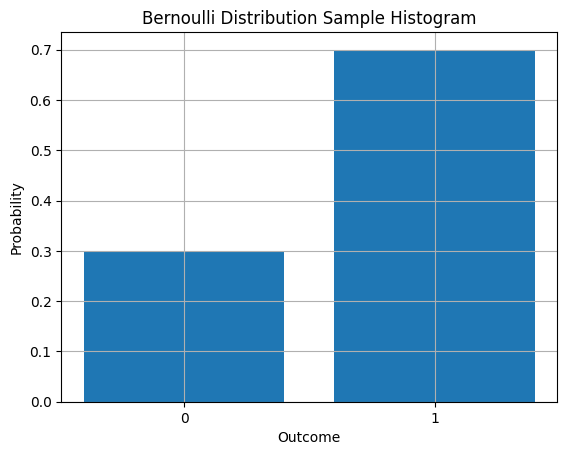

In [10]:
# Plotting the histogram of generated samples
plt.hist(samples, bins=[-0.5, 0.5, 1.5], align='mid', rwidth=0.8, density=True)
plt.xticks([0, 1])
plt.title('Bernoulli Distribution Sample Histogram')
plt.xlabel('Outcome')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

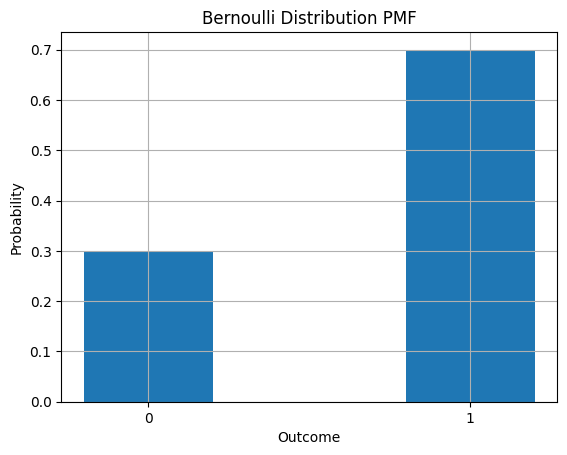

In [11]:
# Plotting the PMF
outcomes = [0, 1]
pmf_values = [bernoulli.pmf(0, p), bernoulli.pmf(1, p)]
plt.bar(outcomes, pmf_values, width=0.4)
plt.xticks([0, 1])
plt.title('Bernoulli Distribution PMF')
plt.xlabel('Outcome')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

## Binomial

### Generating

In [ ]:
# Generate 10 random samples from a binomial distribution
# with n trials and a p probability of success
samples = np.random.binomial(n=n, p=p, size=10)
print(samples)

In [22]:
samples = np.random.binomial(n=n, p=p, size=1000)

### Distribution

In [5]:
#define x and y as symbolic variables
x, y, p, n = symbols('x y p n', real=True, positive=True)

In [6]:
nValue = 10  # Number of trials
pValue = 0.6 # Probability of success

#### Probability Mass Function (`.pmf`)

The probability of getting exactly $k$ successes in $n$ independent Bernoulli trials (with the same rate $p$) is given by the probability mass function:
$$\binom{n}{k}p^k(1-p)^{n-k}$$
where $\binom{n}{k} = \frac{n!}{k!(n-k)!}$

In [7]:
pmf = binomial(n, x)*p**x*(1-p)**(n-x)
pmf

p**x*(1 - p)**(n - x)*binomial(n, x)

In [10]:
xValue = 9
display(pmf)
print(binom.pmf(xValue, p=pValue, n=nValue), 
      pmf.subs([(x, xValue), (p, pValue), (n, nValue)]).evalf(), 
      pmf.evalf(subs={x: xValue, p: pValue, n: nValue}))

p**x*(1 - p)**(n - x)*binomial(n, x)

0.04031078399999996 0.0403107840000000 0.0403107840000000


In [12]:
# Probability of getting exactly 3 heads in 5 coin flips
pmf_value = binom.pmf(k=3, n=nValue, p=pValue)
print(f"Probability of exactly 3 heads: {pmf_value}")

Probability of exactly 3 heads: 0.042467327999999964


#### Cumulative Distribution Function (`.cdf`)

In [13]:
cdf = summation(pmf, (x, 0, y))
cdf

Piecewise((-p**(y + 1)*(1 - p)**(n - y - 1)*gamma(n + 1)*hyper((1, -n + y + 1), (y + 2,), p/(p - 1))/(gamma(n - y)*gamma(y + 2)) + (1 - p)**n*(-p/(p - 1) + 1)**n, p*Abs(1/(p - 1)) <= 1), (Sum(p**x*(1 - p)**(n - x)*binomial(n, x), (x, 0, y)), True))

In [14]:
xValue = 9
display(cdf)
print(binom.cdf(xValue, p=pValue, n=nValue), 
      cdf.subs([(y, xValue), (p, pValue), (n, nValue)]).evalf(), 
      cdf.evalf(subs={y: xValue, p: pValue, n: nValue}))

Piecewise((-p**(y + 1)*(1 - p)**(n - y - 1)*gamma(n + 1)*hyper((1, -n + y + 1), (y + 2,), p/(p - 1))/(gamma(n - y)*gamma(y + 2)) + (1 - p)**n*(-p/(p - 1) + 1)**n, p*Abs(1/(p - 1)) <= 1), (Sum(p**x*(1 - p)**(n - x)*binomial(n, x), (x, 0, y)), True))

0.9939533824 0.993953382400000 0.993953382400000


What is the probability of getting at least one head on three coin flips expressed as a percentage to one decimal place?

In [59]:
s_value = 1 - binom.cdf(0, n=3, p=0.5)
print(f"Probability of getting at least one head on three coin flips: {100*s_value}")

Probability of getting at least one head on three coin flips: 87.5


In [18]:
cdf_value = binom.cdf(k=2, n=nValue, p=pValue)
print(f"Probability of 2 or fewer heads: {cdf_value}")

Probability of 2 or fewer heads: 0.012294553600000006


#### Quantiles (`.ppf`)

In [ ]:
cdf_value = 0.1
ppf = solve(cdf-cdf_value, y)[0]
print(ppf)

In [16]:
# Quantile of getting 2 or fewer heads in 5 coin flips
ppf_value = binom.ppf(0.7, n=nValue, p=pValue)
print(f"Quantile of 0.7: {ppf_value}")

Quantile of 0.7: 7.0


#### Mean or expected value (`.mean`)

In [17]:
mean = summation(pmf*x, (x, 0, n))
mean

Piecewise((p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 1)*gamma(n + 1)/gamma(n), ((n <= 1) & (p*Abs(1/(p - 1)) <= 1)) | ((n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Sum(p**x*x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))

In [18]:
display(mean)
print(binom.mean( p=pValue, n=nValue), 
      mean.subs([(y, xValue), (p, pValue), (n, nValue)]).evalf(), 
      mean.evalf(subs={y: xValue, p: pValue, n: nValue}))

Piecewise((p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 1)*gamma(n + 1)/gamma(n), ((n <= 1) & (p*Abs(1/(p - 1)) <= 1)) | ((n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Sum(p**x*x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))

6.0 6.00000000000000 6.00000000000000


#### Variances (`.var`) and Standard Deviation (`.std`)

In [19]:
var = summation(pmf*(x-mean)**2, (x, 0, n))
var

Piecewise((p**2*(1 - p)**(2*n - 2)*(-p/(p - 1) + 1)**(2*n - 2)*Piecewise(((1 - p)**n*(-p/(p - 1) + 1)**n, p*Abs(1/(p - 1)) <= 1), (Sum(p**x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))*gamma(n + 1)**2/gamma(n)**2 - 2*p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 1)*Piecewise((p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 1)*gamma(n + 1)/gamma(n), ((n <= 1) & (p*Abs(1/(p - 1)) <= 1)) | ((n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Sum(p**x*x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))*gamma(n + 1)/gamma(n) + Piecewise((p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 2)*(-n*p/(p - 1) + 1)*gamma(n + 1)/gamma(n), ((n <= 1) & (p*Abs(1/(p - 1)) < 1)) | ((n > 2) & (p*Abs(1/(p - 1)) <= 1)) | ((n <= 2) & (n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Sum(p**x*x**2*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True)), ((n <= 1) & (p*Abs(1/(p - 1)) <= 1)) | ((n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Piecewise(((1 - p)**n*(-p/(p - 1) + 1)**n, p*Abs(1/(p - 1)) <= 1), (Sum(p**x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n

In [20]:
display(var)
print(binom.var( p=pValue, n=nValue), 
      var.subs([(y, xValue), (p, pValue), (n, nValue)]).evalf(), 
      var.evalf(subs={y: xValue, p: pValue, n: nValue}))

Piecewise((p**2*(1 - p)**(2*n - 2)*(-p/(p - 1) + 1)**(2*n - 2)*Piecewise(((1 - p)**n*(-p/(p - 1) + 1)**n, p*Abs(1/(p - 1)) <= 1), (Sum(p**x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))*gamma(n + 1)**2/gamma(n)**2 - 2*p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 1)*Piecewise((p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 1)*gamma(n + 1)/gamma(n), ((n <= 1) & (p*Abs(1/(p - 1)) <= 1)) | ((n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Sum(p**x*x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))*gamma(n + 1)/gamma(n) + Piecewise((p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 2)*(-n*p/(p - 1) + 1)*gamma(n + 1)/gamma(n), ((n <= 1) & (p*Abs(1/(p - 1)) < 1)) | ((n > 2) & (p*Abs(1/(p - 1)) <= 1)) | ((n <= 2) & (n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Sum(p**x*x**2*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True)), ((n <= 1) & (p*Abs(1/(p - 1)) <= 1)) | ((n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Piecewise(((1 - p)**n*(-p/(p - 1) + 1)**n, p*Abs(1/(p - 1)) <= 1), (Sum(p**x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n

2.4000000000000004 2.40000000000000 2.40000000000000


In [21]:
std = sqrt(var)
std

Piecewise((sqrt(p**2*(1 - p)**(2*n - 2)*(-p/(p - 1) + 1)**(2*n - 2)*Piecewise(((1 - p)**n*(-p/(p - 1) + 1)**n, p*Abs(1/(p - 1)) <= 1), (Sum(p**x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))*gamma(n + 1)**2/gamma(n)**2 - 2*p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 1)*Piecewise((p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 1)*gamma(n + 1)/gamma(n), ((n <= 1) & (p*Abs(1/(p - 1)) <= 1)) | ((n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Sum(p**x*x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))*gamma(n + 1)/gamma(n) + Piecewise((p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 2)*(-n*p/(p - 1) + 1)*gamma(n + 1)/gamma(n), ((n <= 1) & (p*Abs(1/(p - 1)) < 1)) | ((n > 2) & (p*Abs(1/(p - 1)) <= 1)) | ((n <= 2) & (n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Sum(p**x*x**2*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))), ((n <= 1) & (p*Abs(1/(p - 1)) <= 1)) | ((n > 1) & (p*Abs(1/(p - 1)) <= 1))), (sqrt(Piecewise(((1 - p)**n*(-p/(p - 1) + 1)**n, p*Abs(1/(p - 1)) <= 1), (Sum(p**x*(1 - p)**(n - x)*binomial(n, x

In [22]:
display(std)
print(binom.std( p=pValue, n=nValue), 
      std.subs([(y, xValue), (p, pValue), (n, nValue)]).evalf(), 
      std.evalf(subs={y: xValue, p: pValue, n: nValue}))

Piecewise((sqrt(p**2*(1 - p)**(2*n - 2)*(-p/(p - 1) + 1)**(2*n - 2)*Piecewise(((1 - p)**n*(-p/(p - 1) + 1)**n, p*Abs(1/(p - 1)) <= 1), (Sum(p**x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))*gamma(n + 1)**2/gamma(n)**2 - 2*p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 1)*Piecewise((p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 1)*gamma(n + 1)/gamma(n), ((n <= 1) & (p*Abs(1/(p - 1)) <= 1)) | ((n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Sum(p**x*x*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))*gamma(n + 1)/gamma(n) + Piecewise((p*(1 - p)**(n - 1)*(-p/(p - 1) + 1)**(n - 2)*(-n*p/(p - 1) + 1)*gamma(n + 1)/gamma(n), ((n <= 1) & (p*Abs(1/(p - 1)) < 1)) | ((n > 2) & (p*Abs(1/(p - 1)) <= 1)) | ((n <= 2) & (n > 1) & (p*Abs(1/(p - 1)) <= 1))), (Sum(p**x*x**2*(1 - p)**(n - x)*binomial(n, x), (x, 0, n)), True))), ((n <= 1) & (p*Abs(1/(p - 1)) <= 1)) | ((n > 1) & (p*Abs(1/(p - 1)) <= 1))), (sqrt(Piecewise(((1 - p)**n*(-p/(p - 1) + 1)**n, p*Abs(1/(p - 1)) <= 1), (Sum(p**x*(1 - p)**(n - x)*binomial(n, x

1.5491933384829668 1.54919333848297 1.54919333848297


### Visualization

In [19]:
# Create an array of possible number of successes
k_values = np.arange(0, n + 1)

# Calculate the PMF for each k_value
pmf_values = binom.pmf(k_values, n=n, p=p)

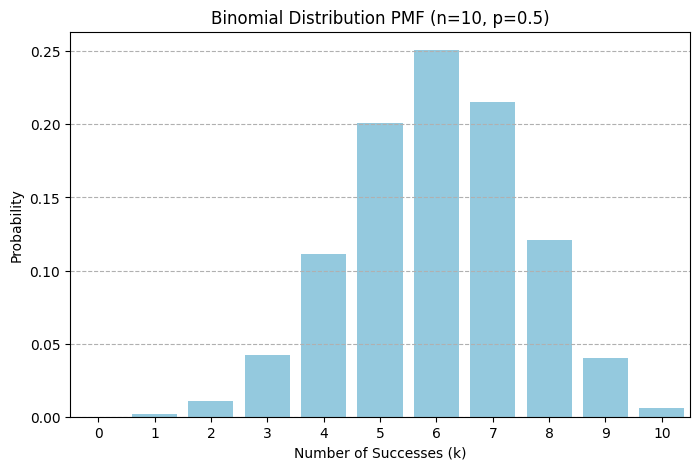

In [20]:
# Plot the PMF
plt.figure(figsize=(8, 5))
sns.barplot(x=k_values, y=pmf_values, color='skyblue')
plt.title('Binomial Distribution PMF (n=10, p=0.5)')
plt.xlabel('Number of Successes (k)')
plt.ylabel('Probability')
plt.grid(axis='y', linestyle='--')
plt.show()

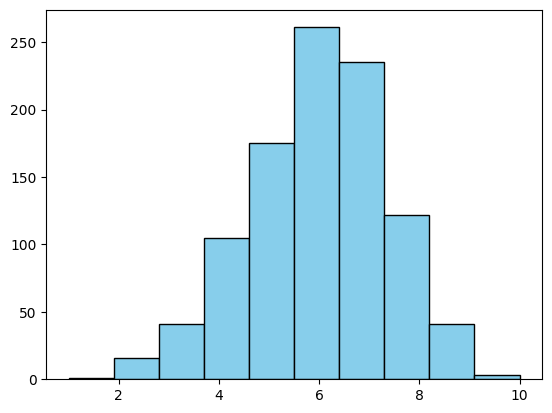

In [23]:
plt.hist(samples, bins=10, edgecolor='black', color='skyblue') # bins=30 creates 30 equal-width bins
plt.show()

### Financial excercises

#### Cash Flow Forecasting

**Scenario**: A company has 50 clients, and each client has a 90% chance of making their payment on time. 

**Question**: What is the probability of receiving payments from exactly 48 clients?

**Application**: Use the binomial formula with $n=50, k=48,$ and $p=0.90$ to find the probability, helping with liquidity management. 

In [35]:
n=50
p=0.9
k=48

In [36]:
pmf_value = binom.pmf(k=k, n=n, p=p)
print(f"The probability of receiving payments from exactly 48 clients: {pmf_value}")

The probability of receiving payments from exactly 48 clients: 0.07794289665391535


In [37]:
# Create an array of possible number of successes
k_values = np.arange(0, n + 1)

# Calculate the PMF for each k_value
pmf_values = binom.pmf(k_values, n, p)

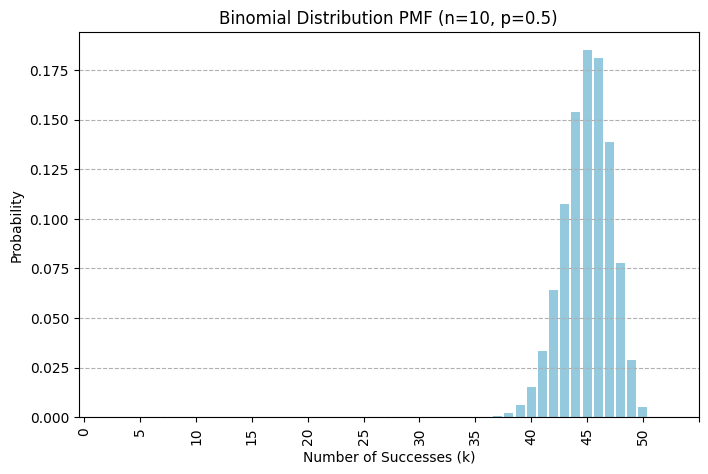

In [39]:
# Plot the PMF
plt.figure(figsize=(8, 5))
sns.barplot(x=k_values, y=pmf_values, color='skyblue')
plt.xticks(np.arange(0, n+6, step=5), rotation=90)  # Set label locations.
# plt.xticks(rotation=90)
plt.title('Binomial Distribution PMF (n=10, p=0.5)')
plt.xlabel('Number of Successes (k)')
plt.ylabel('Probability')
plt.grid(axis='y', linestyle='--')
plt.show()

#### Credit Risk Assessment

**Scenario**: A bank holds 100 loans, and each loan has a 5% chance of defaulting. 

**Question**: What is the probability that exactly 3 of these loans will default?

**Application**: Apply the binomial distribution with $n=100, r=3$, and $p=0.05$ to estimate the number of defaults and assess overall risk.

In [28]:
n=100
k=3
p=0.05

In [30]:
pmf_value = binom.pmf(k=k, n=n, p=p)
print(f"The probability that exactly 3 of these loans will default: {pmf_value}")

The probability that exactly 3 of these loans will default: 0.13957567793089534


In [32]:
# Create an array of possible number of successes
k_values = np.arange(0, n + 1)

# Calculate the PMF for each k_value
pmf_values = binom.pmf(k_values, n, p)

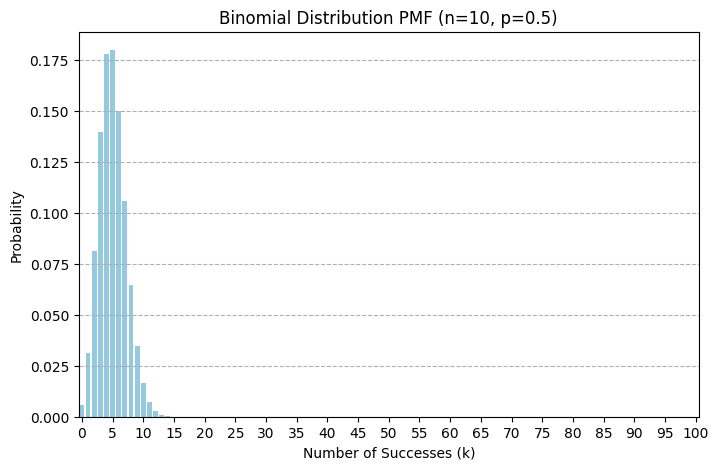

In [33]:
# Plot the PMF
plt.figure(figsize=(8, 5))
sns.barplot(x=k_values, y=pmf_values, color='skyblue')
plt.xticks(np.arange(0, 101, step=5))  # Set label locations.
# plt.xticks(rotation=90)
plt.title('Binomial Distribution PMF (n=10, p=0.5)')
plt.xlabel('Number of Successes (k)')
plt.ylabel('Probability')
plt.grid(axis='y', linestyle='--')
plt.show()

#### Credit risk: Loan portfolio default probability

A bank has a portfolio of 20 independent personal loans. 
The historical probability of any single customer defaulting on a loan is 10%.

In [40]:
# Determine the number of trials (n) and the probability of success (p). 
# A "success" in this case is a loan default.
n=20
p=0.1
q=1-p

In [41]:
# Calculate the probability of a specific outcome: 
# Find the probability that exactly 3 customers in the portfolio will default.
pmf_value = binom.pmf(k=3, n=n, p=p)
print(f"chance of exactly 3 customers defaulting: {pmf_value}")

chance of exactly 3 customers defaulting: 0.19011987137619904


In [42]:
# Calculate the cumulative probability: 
# Find the probability that no more than 2 customers will default.
cdf_value = binom.cdf(k=2, n=n, p=p)
print(f"chance of 2 or fewer customers defaulting: {cdf_value}")

chance of 2 or fewer customers defaulting: 0.6769268051894659


In [44]:
# Calculate the mean and standard deviation: 
# Determine the expected number of defaults and the spread of possible outcomes.
mean, variance = binom.stats(n, p)
print(f"mean: {mean}\n standard deviation: {np.sqrt(variance)}")

mean: 2.0
 standard deviation: 1.3416407864998738


In [45]:
1-binom.cdf(k=14, n=n, p=p)

np.float64(9.481304630298837e-12)

#### Option pricing: The single-period binomial model

A stock is currently trading at $50. 
In one year, its price is expected to either increase by 20% or decrease by 10%. 
A European call option on this stock has a strike price of $52 and an expiration date of one year. 
The annual risk-free interest rate is 5%.

In [46]:
# Construct the binomial tree
u = 50 * (1+0.2)
d = 50 * (1-0.1)

In [47]:
# Calculate the option's payoffs
Cu = max(u - 52, 0)
Cd = max(d - 52, 0)
print(f"Up-state payoff (Cu): {Cu}")
print(f"Down-state payoff (Cd): {Cd}")

Up-state payoff (Cu): 8.0
Down-state payoff (Cd): 0


In [48]:
# Find the risk-neutral probability (\(p\))
r=0.05
p = ((1+r)*50-d)/(u-d)

In [49]:
# Value the call option (\(C_{0}\))
C0 = (p*Cu+(1-p)*Cd)/(1+r)

## Poisson Random Variables

The Poisson distribution is a discrete probability distribution that models the number of events occurring within a fixed interval of time or space, given a known constant average rate of occurrence and independence of events.

In [23]:
lamb = 5

### Generating

**Lambda (λ)**: The average rate at which events occur within the given interval. 
This is the single parameter that characterizes the Poisson distribution

In [6]:
samples = poisson.rvs(lamb, size=1000)
print(f"First 10 samples: {samples[:10]}")

First 10 samples: [10  8  6  1  2  5  3  3  8  8]


### Distribution

In [24]:
k, y, lambd = symbols('k y lambda', real=True, positive=True)

In [25]:
x=3

#### Probability Mass Function (`.pmf`)

Under a Poisson distribution with the expectation of $\lambda$ events in a given interval, the probability of $k$ events in the same interval is
$$\frac{\lambda^ke^{-\lambda}}{k!}$$

In [26]:
pmf = lambd**k * exp(-lambd)/factorial(k)
pmf

lambda**k*exp(-lambda)/factorial(k)

In [106]:
probability = poisson.pmf(x, lamb)
print(f"P(X={x} | λ={lamb}) = {probability}")

P(X=3 | λ=5) = 0.1403738958142805


In [27]:
xValue = 9
display(pmf)
print(poisson.pmf(x, lamb), 
      pmf.subs([(k, x), (lambd, lamb)]).evalf(), 
      pmf.evalf(subs={k: x, lambd: lamb}))

lambda**k*exp(-lambda)/factorial(k)

0.1403738958142805 0.140373895814281 0.140373895814281


#### Cumulative Distribution Function (`.cdf`)

In [28]:
cdf = simplify( summation(pmf, (k, 0, y)))
cdf 

1 - lowergamma(y + 1, lambda)/gamma(y + 1)

In [29]:
xValue = 9
display(cdf)
print(poisson.cdf(x, lamb), 
      cdf.subs([(y, x), (lambd, lamb)]).evalf(), 
      cdf.evalf(subs={y: x, lambd: lamb}))

1 - lowergamma(y + 1, lambda)/gamma(y + 1)

0.2650259152973616 0.265025915297362 0.265025915297362


#### Quantiles (`.ppf`)

In [65]:
expand(cdf)

1 - lowergamma(y + 1, lambda)/gamma(y + 1)

In [ ]:
cdfValue = 0.2
solve(cdf-cdfValue, y)

In [ ]:
ppf = solve(cdf-cdfValue, y)[0]
print(ppf)

In [69]:

ppfValue = poisson.ppf(cdfValue, lamb)
print(f"P(X<={ppfValue} | λ={lamb}) = {cdfValue}")

P(X<=3.0 | λ=5) = 0.2


#### Mean or expected value (`.mean`)

In [31]:
mean = summation(pmf*k, (k, 0, oo))
mean

lambda

In [33]:
display(mean)
print(poisson.mean(lamb), 
      mean.subs([(y, x), (lambd, lamb)]).evalf(), 
      mean.evalf(subs={y: x, lambd: lamb}))

lambda

5.0 5.00000000000000 5.00000000000000


#### Variances (`.var`) and Standard Deviation (`.std`)

In [34]:
var = simplify(summation(pmf*(k-mean)**2, (k, 0, oo)))
var

lambda

In [36]:
display(mean)
print(poisson.var(lamb), 
      var.subs([(y, x), (lambd, lamb)]).evalf(), 
      var.evalf(subs={y: x, lambd: lamb}))

lambda

5.0 5.00000000000000 5.00000000000000


In [38]:
std = sqrt(var)
std

sqrt(lambda)

In [39]:
display(std)
print(poisson.std(lamb), 
      std.subs([(y, x), (lambd, lamb)]).evalf(), 
      std.evalf(subs={y: x, lambd: lamb}))

sqrt(lambda)

2.23606797749979 2.23606797749979 2.23606797749979


### Visualization

In [88]:
x = np.arange(0, 10)  # Range of possible events
pmf_values = poisson.pmf(x, lamb)

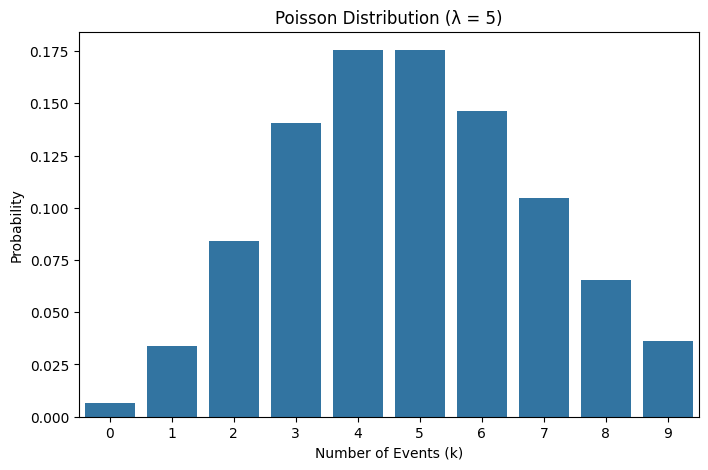

In [89]:
plt.figure(figsize=(8, 5))
sns.barplot(x=x, y=pmf_values)
plt.title(f'Poisson Distribution (λ = {lamb})')
plt.xlabel('Number of Events (k)')
plt.ylabel('Probability')
plt.show()

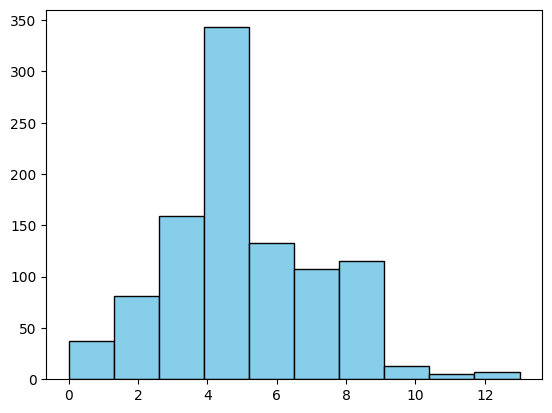

In [91]:
plt.hist(samples, bins=10, edgecolor='black', color='skyblue') 
# bins=30 creates 30 equal-width bins
plt.show()

### Financial Excercises

#### Credit risk modeling for a loan portfolio

A bank has a large portfolio of consumer loans. 
Based on historical data, the average number of loan defaults in this portfolio is 3 per quarter. 
Assuming defaults occur randomly and independently, a Poisson distribution is a suitable model.

In [60]:
lam = 3
k = 4

In [61]:
probability = poisson.pmf(k, lam)
print(f"P(X={k} | λ={lam}) = {probability}")

P(X=4 | λ=3) = 0.16803135574154085


In [62]:
cumulative_probability = poisson.cdf(k, lam)
print(f"P(X<={k} | λ={lam}) = {cumulative_probability}")

P(X<=4 | λ=3) = 0.8152632445237722


In [63]:
print(f"P(X > {k} | λ={lam}) = {1-cumulative_probability}")

P(X > 4 | λ=3) = 0.1847367554762278


#### Operational risk in a financial institution

A fintech company's trading server experiences an average of 1.2 system failures per month. 
The failures are rare and occur randomly.

In [64]:
lam = 1.2
k = 3

In [65]:
# What is the probability of exactly k system failures next month?
probability = poisson.pmf(k, lam)
print(f"P(X={k} | λ={lam}) = {probability}")

P(X=3 | λ=1.2) = 0.08674393303071422


In [66]:
# What is the probability of fewer than 2 system failures next month?
k = 2
cumulative_probability = poisson.cdf(k-1, lam)
print(f"P(X<={k} | λ={lam}) = {cumulative_probability}")

P(X<=2 | λ=1.2) = 0.6626272662068446


In [67]:
# The company defines a "crisis month" as one with 4 or more system failures. 
# What is the probability of a crisis month?
k = 4
cumulative_probability = poisson.cdf(k-1, lam)
print(f"P(X<={k-1} | λ={lam}) = {cumulative_probability}")

P(X<=3 | λ=1.2) = 0.9662310318143443


In [68]:
print(f"P(X>={k} | λ={lam}) = {1-cumulative_probability}")

P(X>=4 | λ=1.2) = 0.03376896818565567


#### Insurance claims frequency

An insurance company receives an average of 6 claims per week for a certain type of policy. 
Claims are filed independently and at a constant rate.

In [ ]:
lam = 6
k = 8

In [69]:
# What is the probability of receiving exactly 8 claims next week?
probability = poisson.pmf(k, lam)
print(f"P(X={k} | λ={lam}) = {probability}")

P(X=4 | λ=1.2) = 0.026023179909214246


#### Portfolio rebalancing

An investment analyst uses a statistical model where the number of buy or sell orders for a particular stock follows a Poisson distribution. 
The analyst observes an average of 4 trades per minute during a 10-minute trading period.

In [70]:
lam = 4
k = 5

In [71]:
# What is the probability of observing exactly 4 trades in a single minute?
probability = poisson.pmf(k, lam)
print(f"P(X={k} | λ={lam}) = {probability}")

P(X=5 | λ=4) = 0.1562934518505317


In [72]:
# What is the probability of observing 10 or more trades over the 10-minute period?
lam = 40
k = 10
cumulative_probability = poisson.cdf(k-1, lam)
print(f"P(X<={k-1} | λ={lam}) = {cumulative_probability}")

P(X<=9 | λ=40) = 3.925932226286184e-09


In [73]:
print(f"P(X>={k} | λ={lam}) = {1-cumulative_probability}")

P(X>=10 | λ=40) = 0.9999999960740678


## References

- [Poisson distribution by Marco Taboga, PhD](https://www.statlect.com/probability-distributions/Poisson-distribution)
- [Poisson Distribution: A Comprehensive Guide](https://www.datacamp.com/tutorial/poisson-distribution)